Наблюдаемые пики 2009: {'Москва': np.int64(44), 'Санкт-Петербург': np.int64(47), 'Новосибирск': np.int64(47), 'Екатеринбург': np.int64(46), 'Нижний_Новгород': np.int64(47), 'Самара': np.int64(47), 'Омск': np.int64(48), 'Казань': np.int64(46), 'Челябинск': np.int64(44), 'Уфа': np.int64(45), 'Пермь': np.int64(45), 'Ростов-на-Дону': np.int64(48)}
Optimization terminated successfully.
         Current function value: 1.107143
         Iterations: 28
         Function evaluations: 97

Оптимальные параметры:
  β              = 0.5025
  γ              = 0.1769
  R₀             = 2.841
  mobility_scale = 0.00472
  seed_Moscow    = 58.8
  Loss           = 1.107

Результаты по городам (2009):
          Город  Наблюдаемый_пик  Модель_с_транспортом  Модель_без_транспорта  Ошибка_с_транспортом  Ошибка_без_транспорта
         Москва               44                  45.7                   45.6                  1.71                   1.57
Санкт-Петербург               47                  45.9        

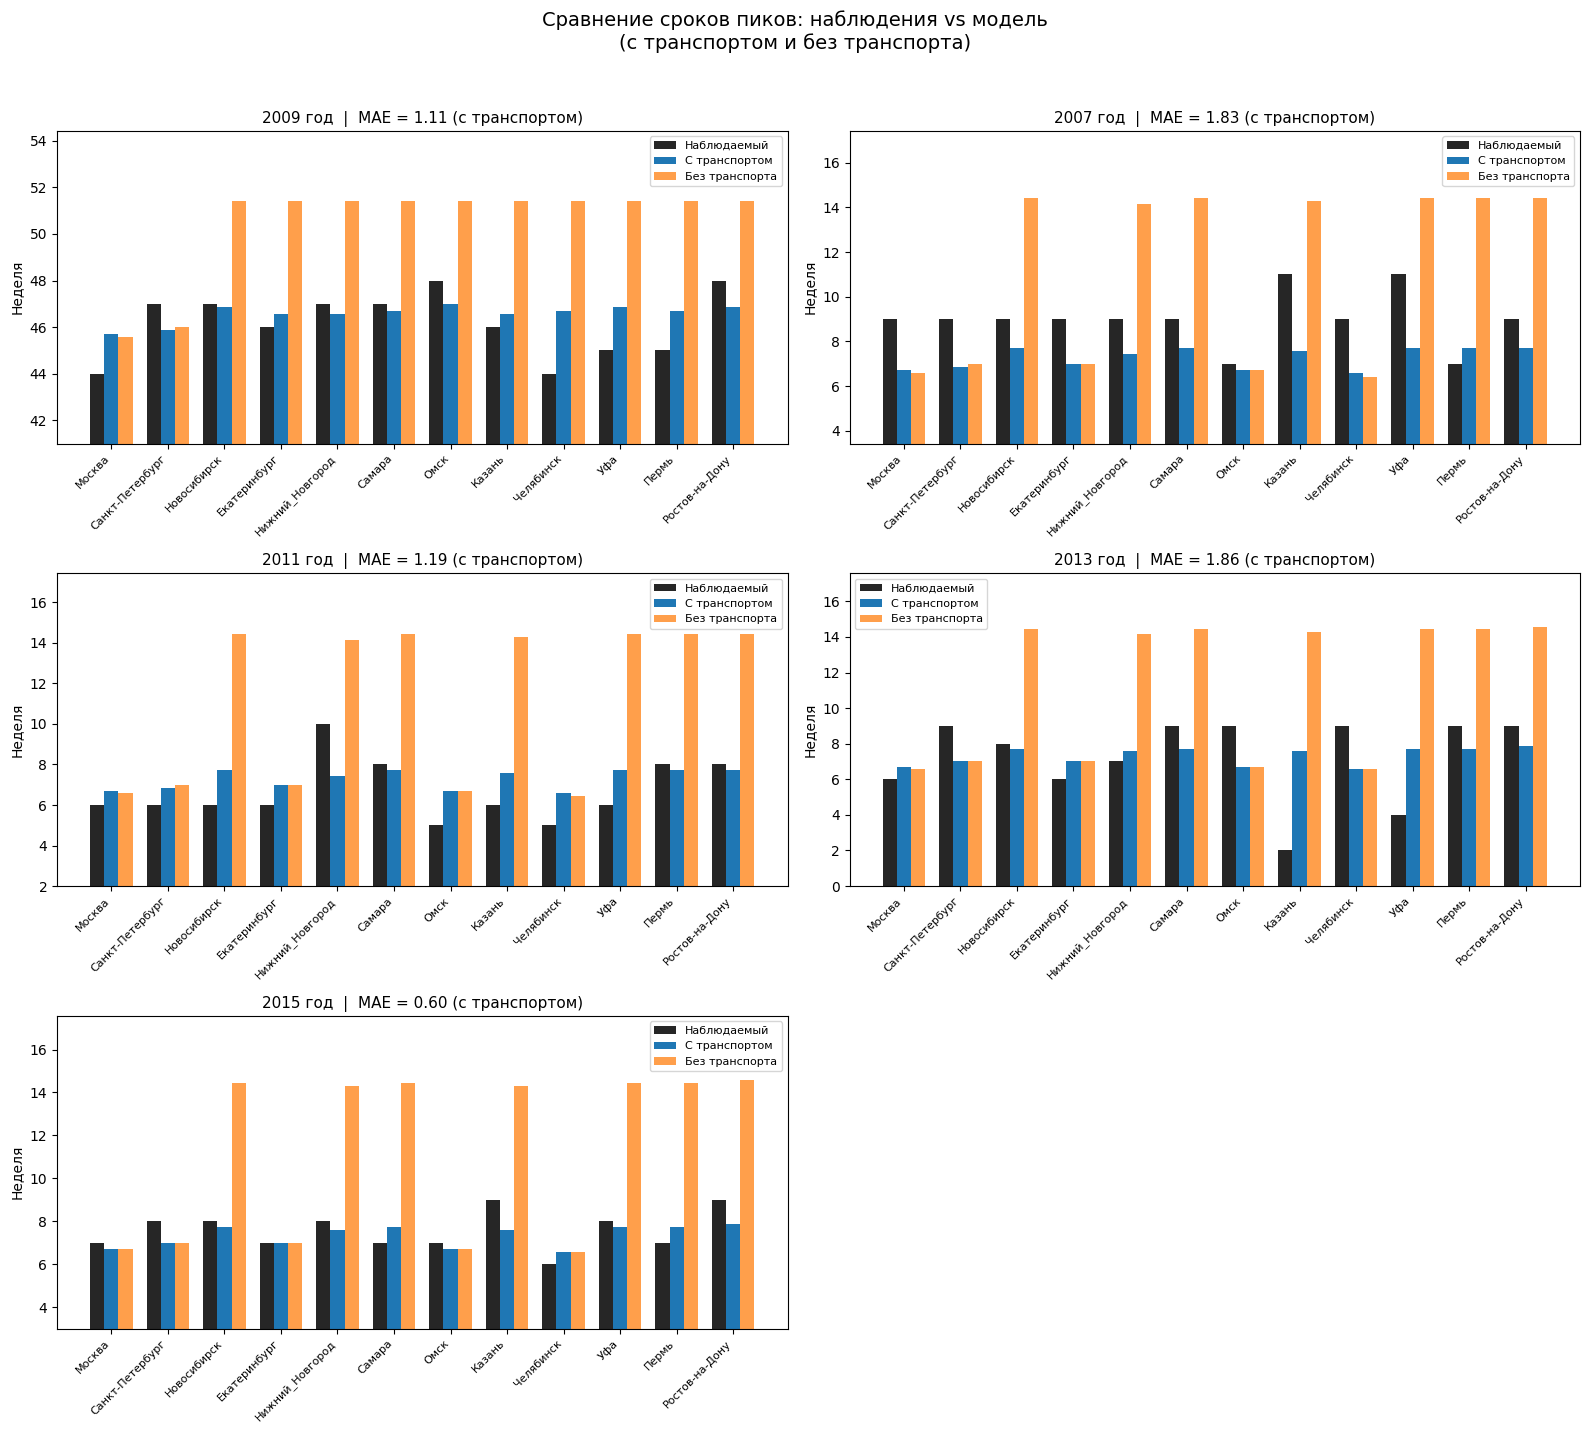

In [ ]:
import pandas as pd
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


CITIES = [
    'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург',
    'Нижний_Новгород', 'Самара', 'Омск', 'Казань',
    'Челябинск', 'Уфа', 'Пермь', 'Ростов-на-Дону'
]

REL_FLOW = np.array([
    [0.00, 1.00, 0.35, 0.55, 0.70, 0.40, 0.25, 0.50, 0.40, 0.35, 0.40, 0.35],
    [1.00, 0.00, 0.12, 0.18, 0.25, 0.15, 0.08, 0.18, 0.12, 0.12, 0.15, 0.12],
    [0.35, 0.12, 0.00, 0.30, 0.10, 0.08, 0.45, 0.12, 0.20, 0.12, 0.15, 0.06],
    [0.55, 0.18, 0.30, 0.00, 0.20, 0.18, 0.25, 0.25, 0.55, 0.35, 0.50, 0.10],
    [0.70, 0.25, 0.10, 0.20, 0.00, 0.25, 0.08, 0.45, 0.15, 0.18, 0.20, 0.12],
    [0.40, 0.15, 0.08, 0.18, 0.25, 0.00, 0.08, 0.30, 0.15, 0.25, 0.15, 0.20],
    [0.25, 0.08, 0.45, 0.25, 0.08, 0.08, 0.00, 0.10, 0.18, 0.12, 0.12, 0.05],
    [0.50, 0.18, 0.12, 0.25, 0.45, 0.30, 0.10, 0.00, 0.18, 0.30, 0.22, 0.12],
    [0.40, 0.12, 0.20, 0.55, 0.15, 0.15, 0.18, 0.18, 0.00, 0.30, 0.35, 0.08],
    [0.35, 0.12, 0.12, 0.35, 0.18, 0.25, 0.12, 0.30, 0.30, 0.00, 0.28, 0.10],
    [0.40, 0.15, 0.15, 0.50, 0.20, 0.15, 0.12, 0.22, 0.35, 0.28, 0.00, 0.08],
    [0.35, 0.12, 0.06, 0.10, 0.12, 0.20, 0.05, 0.12, 0.08, 0.10, 0.08, 0.00],
], dtype=float)

REL_FLOW = (REL_FLOW + REL_FLOW.T) / 2.0
np.fill_diagonal(REL_FLOW, 0.0)


def build_realistic_M(scale, N):
    flow = REL_FLOW * N[:, None]
    flow = flow * (N[None, :] / N.mean())
    total = flow.sum()
    if total > 0:
        flow *= (scale * N.sum()) / total
    return flow / N[:, None]


def sir_metapop(y, t, beta, gamma, M, N):
    n = len(N)
    S = y[0:n]
    I = y[n:2*n]
    R = y[2*n:3*n]

    dS = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)

    for i in range(n):
        force = beta * I[i] / N[i]
        dS[i] = -force * S[i]
        dI[i] = force * S[i] - gamma * I[i]
        dR[i] = gamma * I[i]

        for j in range(n):
            if i != j:
                dS[i] += M[j, i] * S[j] - M[i, j] * S[i]
                dI[i] += M[j, i] * I[j] - M[i, j] * I[i]
                dR[i] += M[j, i] * R[j] - M[i, j] * R[i]

    return np.concatenate([dS, dI, dR])


def get_model_weeks(beta, gamma, scale, seed_moscow, N, cities,
                    start_week=40.0, extra_seeds=None, t_max=80):
    n = len(N)
    M = build_realistic_M(scale, N)

    I0 = np.zeros(n)
    I0[0] = max(seed_moscow, 1.0)
    I0[1] = max(seed_moscow * 0.18, 1.0)

    if extra_seeds:
        for city_name, val in extra_seeds.items():
            if city_name in cities:
                I0[cities.index(city_name)] = val

    y0 = np.concatenate([N.copy(), I0, np.zeros(n)])
    t = np.linspace(0, t_max, t_max + 1)

    sol = odeint(sir_metapop, y0, t, args=(beta, gamma, M, N), mxstep=5000)
    rate = sol[:, n:2*n] / N * 100000.0
    peaks_days = np.argmax(rate, axis=0)

    return start_week + peaks_days / 7.0



def calculate_peak_metrics(obs, pred, name=""):
    errors = pred - obs
    abs_errors = np.abs(errors)

    metrics = {
        'MAE': np.mean(abs_errors),
        'RMSE': np.sqrt(np.mean(errors**2)),
        'MedAE': np.median(abs_errors),
        'MaxAE': np.max(abs_errors),
        'Bias': np.mean(errors),
        'Hit_Rate_1': np.mean(abs_errors <= 1.0),
        'Hit_Rate_2': np.mean(abs_errors <= 2.0),
        'Pearson_r': pearsonr(obs, pred)[0] if len(obs) > 2 else np.nan,
        'Spearman_r': spearmanr(obs, pred)[0] if len(obs) > 2 else np.nan,
    }

    print(f"\n--- Метрики: {name} ---")
    print(f"MAE             : {metrics['MAE']:.2f} недели")
    print(f"RMSE            : {metrics['RMSE']:.2f} недели")
    print(f"MedAE           : {metrics['MedAE']:.2f} недели")
    print(f"MaxAE           : {metrics['MaxAE']:.2f} недели")
    print(f"Bias            : {metrics['Bias']:+.2f} недели")
    print(f"Hit Rate ±1 нед : {metrics['Hit_Rate_1']*100:.1f}%")
    print(f"Hit Rate ±2 нед : {metrics['Hit_Rate_2']*100:.1f}%")
    print(f"Pearson r       : {metrics['Pearson_r']:.3f}")
    print(f"Spearman r      : {metrics['Spearman_r']:.3f}")

    return metrics



df = pd.read_excel('/content/Zab_v_bolshikh_gorodakh.xlsx')
df = df.dropna(subset=['wd_total', 'qty_total'])
df['rate'] = df['wd_total'] / df['qty_total'] * 100000


def get_year_data(year):
    d = df[df['cld_year'] == year].copy()
    obs = (d.loc[d.groupby('town_name')['rate'].idxmax()]
             [['town_name', 'week_number']]
             .set_index('town_name')
             .loc[CITIES])
    obs_weeks = obs['week_number'].values.astype(float)
    N = (d.groupby('town_name')['qty_total']
           .mean()
           .reindex(CITIES)
           .values.astype(float))
    return obs_weeks, N

obs2009, N2009 = get_year_data(2009)
print("Наблюдаемые пики 2009:", dict(zip(CITIES, obs2009.astype(int))))


def loss_2009(x):
    beta, gamma, scale, seed = x
    try:
        mw = get_model_weeks(beta, gamma, scale, seed, N2009, CITIES,
                             start_week=40.0, t_max=75)
        mae = np.mean(np.abs(mw - obs2009))
        r0 = beta / gamma
        pen = 0.0
        if r0 < 1.4 or r0 > 3.3:
            pen += 3.0
        if scale > 0.015:
            pen += 1.5
        return mae + pen
    except Exception:
        return 25.0


x0 = np.array([0.45, 0.19, 0.0045, 60.0])
res = minimize(loss_2009, x0, method='Nelder-Mead',
               options={'maxiter': 120, 'xatol': 1e-3, 'fatol': 0.04, 'disp': True})

best = res.x
beta_opt, gamma_opt, scale_opt, seed_opt = best

print("\nОптимальные параметры:")
print(f"  β              = {beta_opt:.4f}")
print(f"  γ              = {gamma_opt:.4f}")
print(f"  R₀             = {beta_opt / gamma_opt:.3f}")
print(f"  mobility_scale = {scale_opt:.5f}")
print(f"  seed_Moscow    = {seed_opt:.1f}")
print(f"  Loss           = {res.fun:.3f}")

model_mob_2009 = get_model_weeks(beta_opt, gamma_opt, scale_opt, seed_opt,
                                 N2009, CITIES, start_week=40.0)
model_ind_2009 = get_model_weeks(beta_opt, gamma_opt, 1e-9, seed_opt,
                                 N2009, CITIES, start_week=40.0)

comp2009 = pd.DataFrame({
    'Город': CITIES,
    'Наблюдаемый_пик': obs2009.astype(int),
    'Модель_с_транспортом': np.round(model_mob_2009, 1),
    'Модель_без_транспорта': np.round(model_ind_2009, 1),
    'Ошибка_с_транспортом': np.round(np.abs(model_mob_2009 - obs2009), 2),
    'Ошибка_без_транспорта': np.round(np.abs(model_ind_2009 - obs2009), 2)
})

print("\nРезультаты по городам (2009):")
print(comp2009.to_string(index=False))

metrics_mob_2009 = calculate_peak_metrics(obs2009, model_mob_2009, "с транспортом (2009)")
metrics_ind_2009 = calculate_peak_metrics(obs2009, model_ind_2009, "без транспорта (2009)")

comp2009.to_excel('realistic_calibration_2009.xlsx', index=False)



VALIDATION_YEARS = [2007, 2011, 2013, 2015]

all_metrics = {
    '2009_с_транспортом': metrics_mob_2009,
    '2009_без_транспорта': metrics_ind_2009,
}

plot_data = {
    2009: {
        'obs': obs2009,
        'model_mob': model_mob_2009,
        'model_ind': model_ind_2009,
        'mae_mob': metrics_mob_2009['MAE']
    }
}

for year in VALIDATION_YEARS:
    print(f"ВАЛИДАЦИЯ НА {year} ГОДЕ")

    obs, N = get_year_data(year)
    print("Наблюдаемые пики:", dict(zip(CITIES, obs.astype(int))))

    median_peak = np.median(obs)

    if median_peak < 25:
        start_week = 1.0
        extra_seeds = {'Челябинск': 8.0, 'Омск': 5.0, 'Екатеринбург': 3.0}
        t_max = 100
    else:
        start_week = 38.0
        extra_seeds = None
        t_max = 80

    model_mob = get_model_weeks(beta_opt, gamma_opt, scale_opt, seed_opt,
                                N, CITIES, start_week=start_week,
                                extra_seeds=extra_seeds, t_max=t_max)
    model_ind = get_model_weeks(beta_opt, gamma_opt, 1e-9, seed_opt,
                                N, CITIES, start_week=start_week,
                                extra_seeds=extra_seeds, t_max=t_max)

    comp = pd.DataFrame({
        'Город': CITIES,
        f'Наблюдаемый_пик_{year}': obs.astype(int),
        'Модель_с_транспортом': np.round(model_mob, 1),
        'Модель_без_транспорта': np.round(model_ind, 1),
        'Ошибка_с_транспортом': np.round(np.abs(model_mob - obs), 2),
        'Ошибка_без_транспорта': np.round(np.abs(model_ind - obs), 2)
    })

    print("\nРезультаты по городам:")
    print(comp.to_string(index=False))

    print(f"МЕТРИКИ НА {year} ГОДЕ")
    metrics_mob = calculate_peak_metrics(obs, model_mob, f"с транспортом ({year})")
    metrics_ind = calculate_peak_metrics(obs, model_ind, f"без транспорта ({year})")

    all_metrics[f'{year}_с_транспортом'] = metrics_mob
    all_metrics[f'{year}_без_транспорта'] = metrics_ind

    # Сохраняем для графиков
    plot_data[year] = {
        'obs': obs,
        'model_mob': model_mob,
        'model_ind': model_ind,
        'mae_mob': metrics_mob['MAE']
    }

    comp.to_excel(f'realistic_validation_{year}.xlsx', index=False)


metric_names = ['MAE', 'RMSE', 'MedAE', 'MaxAE', 'Bias',
                'Hit_Rate_1', 'Hit_Rate_2', 'Pearson_r', 'Spearman_r']

summary_data = {'Метрика': metric_names}
for key, metrics in all_metrics.items():
    summary_data[key] = [metrics[m] for m in metric_names]

summary = pd.DataFrame(summary_data)

print("СВОДНАЯ ТАБЛИЦА МЕТРИК ПО ВСЕМ ГОДАМ")
print(summary.round(3).to_string(index=False))
summary.to_excel('metrics_summary_all_years.xlsx', index=False)


print("СРАВНЕНИЕ MAE ПО ГОДАМ")
print(f"{'Год':<8} {'С транспортом':>15} {'Без транспорта':>15} {'Улучшение':>12}")
print("-"*55)

mae_rows = []
for year in [2009] + VALIDATION_YEARS:
    mae_mob = all_metrics[f'{year}_с_транспортом']['MAE']
    mae_ind = all_metrics[f'{year}_без_транспорта']['MAE']
    improvement = mae_ind - mae_mob
    print(f"{year:<8} {mae_mob:15.2f} {mae_ind:15.2f} {improvement:12.2f}")
    mae_rows.append({
        'Год': year,
        'MAE_с_транспортом': mae_mob,
        'MAE_без_транспорта': mae_ind,
        'Улучшение': improvement
    })

pd.DataFrame(mae_rows).to_excel('mae_comparison.xlsx', index=False)


years_to_plot = [2009] + VALIDATION_YEARS
n_years = len(years_to_plot)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

x = np.arange(len(CITIES))
w = 0.25

for idx, year in enumerate(years_to_plot):
    ax = axes[idx]
    data = plot_data[year]

    ax.bar(x - w, data['obs'], w, label='Наблюдаемый', color='black', alpha=0.85)
    ax.bar(x, data['model_mob'], w, label='С транспортом', color='tab:blue')
    ax.bar(x + w, data['model_ind'], w, label='Без транспорта', color='tab:orange', alpha=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(CITIES, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Неделя')
    ax.set_title(f'{year} год  |  MAE = {data["mae_mob"]:.2f} (с транспортом)', fontsize=11)
    ax.legend(fontsize=8)

    all_vals = np.concatenate([data['obs'], data['model_mob'], data['model_ind']])
    y_min = max(0, all_vals.min() - 3)
    y_max = all_vals.max() + 3
    ax.set_ylim(y_min, y_max)

if n_years < len(axes):
    for idx in range(n_years, len(axes)):
        fig.delaxes(axes[idx])

plt.suptitle('Сравнение сроков пиков: наблюдения vs модель\n(с транспортом и без транспорта)', fontsize=14, y=1.02)
plt.tight_layout()


for year in years_to_plot:
    data = plot_data[year]
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x - w, data['obs'], w, label='Наблюдаемый', color='black', alpha=0.85)
    ax.bar(x, data['model_mob'], w, label='С транспортом', color='tab:blue')
    ax.bar(x + w, data['model_ind'], w, label='Без транспорта', color='tab:orange', alpha=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(CITIES, rotation=45, ha='right')
    ax.set_ylabel('Неделя')
    ax.set_title(f'{year} год  |  MAE с транспортом = {data["mae_mob"]:.2f}')
    ax.legend()

    all_vals = np.concatenate([data['obs'], data['model_mob'], data['model_ind']])
    ax.set_ylim(max(0, all_vals.min() - 3), all_vals.max() + 3)

    plt.tight_layout()
    plt.close()